In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy import stats
from scipy.stats import rankdata, norm
import seaborn as sns

In [2]:
# import test_salaries.csv as a pandas dataframe
df = pd.read_csv('salaries_3000.csv')
# separate the first 1500 rows of the dataframe into a new dataframe and the last 1500 rows into another dataframe
df_m = df.iloc[:1500]
df_f = df.iloc[1500:]
# only include occupation 5
df_m = df_m[df_m['occupation'] == 5]
df_f = df_f[df_f['occupation'] == 5]

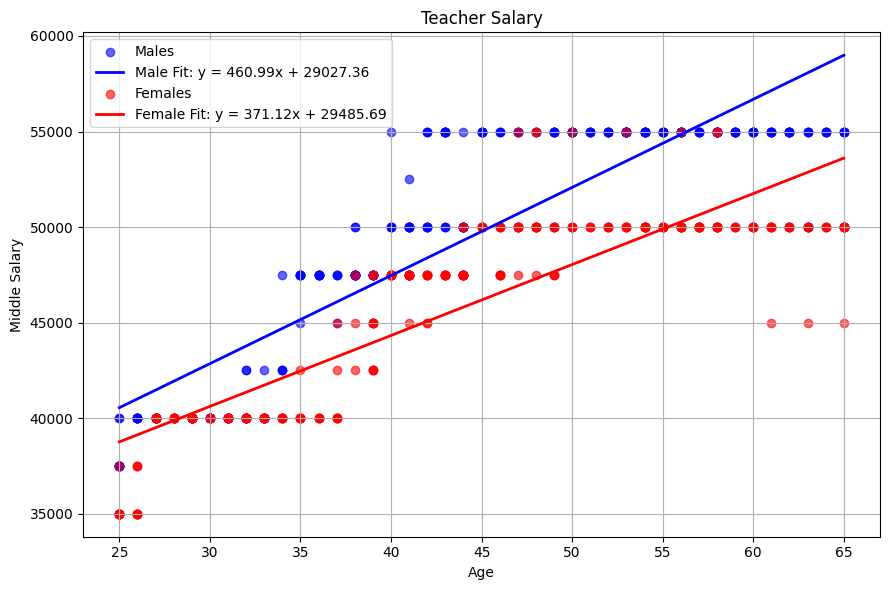

Middle Salary for Males: 49600.00
Middle Salary for Females: 46175.00


In [3]:
# Extract data
ages_m = df_m['age']
salaries_m = df_m['middle_salary']

ages_f = df_f['age']
salaries_f = df_f['middle_salary']

# --- Male regression ---
n_m = len(ages_m)
x_mean_m = sum(ages_m) / n_m
y_mean_m = sum(salaries_m) / n_m
slope_m = sum((ages_m.iloc[i] - x_mean_m) * (salaries_m.iloc[i] - y_mean_m) for i in range(n_m)) / \
          sum((ages_m.iloc[i] - x_mean_m)**2 for i in range(n_m))
intercept_m = y_mean_m - slope_m * x_mean_m

# --- Female regression ---
n_f = len(ages_f)
x_mean_f = sum(ages_f) / n_f
y_mean_f = sum(salaries_f) / n_f
slope_f = sum((ages_f.iloc[i] - x_mean_f) * (salaries_f.iloc[i] - y_mean_f) for i in range(n_f)) / \
          sum((ages_f.iloc[i] - x_mean_f)**2 for i in range(n_f))
intercept_f = y_mean_f - slope_f * x_mean_f

# Regression line values
x_vals = sorted(set(ages_m) | set(ages_f))  # Union of all unique age values
y_vals_m = [slope_m * x + intercept_m for x in x_vals]
y_vals_f = [slope_f * x + intercept_f for x in x_vals]

# --- Plotting ---
plt.figure(figsize=(9, 6))
plt.scatter(ages_m, salaries_m, color='blue', alpha=0.6, label='Males')
plt.plot(x_vals, y_vals_m, color='blue', linewidth=2, label=f'Male Fit: y = {slope_m:.2f}x + {intercept_m:.2f}')

plt.scatter(ages_f, salaries_f, color='red', alpha=0.6, label='Females')
plt.plot(x_vals, y_vals_f, color='red', linewidth=2, label=f'Female Fit: y = {slope_f:.2f}x + {intercept_f:.2f}')

plt.title('Teacher Salary')
plt.xlabel('Age')
plt.ylabel('Middle Salary')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# also print the mean salary for M and F
mean_salary_m = salaries_m.mean() 
mean_salary_f = salaries_f.mean()
print(f'Middle Salary for Males: {mean_salary_m:.2f}')
print(f'Middle Salary for Females: {mean_salary_f:.2f}')

In [4]:
# Extract the salary data and group labels
x = df_m["middle_salary"].values
y = df_f["middle_salary"].values

n1 = len(x)
n2 = len(y)

# Combine data with group labels
all_values = np.concatenate([x, y])
groups = np.array(['M'] * n1 + ['F'] * n2)

# Rank the combined values
ranks = rankdata(all_values)  # average ranks for ties

# Create a DataFrame to see everything clearly
ranked_df = pd.DataFrame({
    'value': all_values,
    'rank': ranks,
    'group': groups
}).sort_values(by='rank').reset_index(drop=True)

print(ranked_df.head(3000))  # see the top 10 ranks values


     value   rank group
0    35000    8.5     F
1    35000    8.5     F
2    35000    8.5     F
3    35000    8.5     F
4    35000    8.5     F
..     ...    ...   ...
595  55000  523.0     M
596  55000  523.0     M
597  55000  523.0     M
598  55000  523.0     M
599  55000  523.0     M

[600 rows x 3 columns]


In [5]:
# Assuming x and y are your arrays for male and female salaries
# Make sure to compare only up to the length of the smaller group
length = min(len(x), len(y))

count_m_greater = 0
count_f_greater = 0
count_m_equal_f = 0
for i in range(length):
    if x[i] > y[i]:
        count_m_greater += 1
    elif x[i] < y[i]:
        count_f_greater += 1
    elif x[i] == y[i]:
        count_m_equal_f += 1

print(f"Number of pairs where male earns more than female: {count_m_greater} out of {length}")
print(f"Number of pairs where female earns more than male: {count_f_greater} out of {length}")
print(f"Number of pairs where male and female earn the same: {count_m_equal_f} out of {length}")


Number of pairs where male earns more than female: 185 out of 300
Number of pairs where female earns more than male: 67 out of 300
Number of pairs where male and female earn the same: 48 out of 300


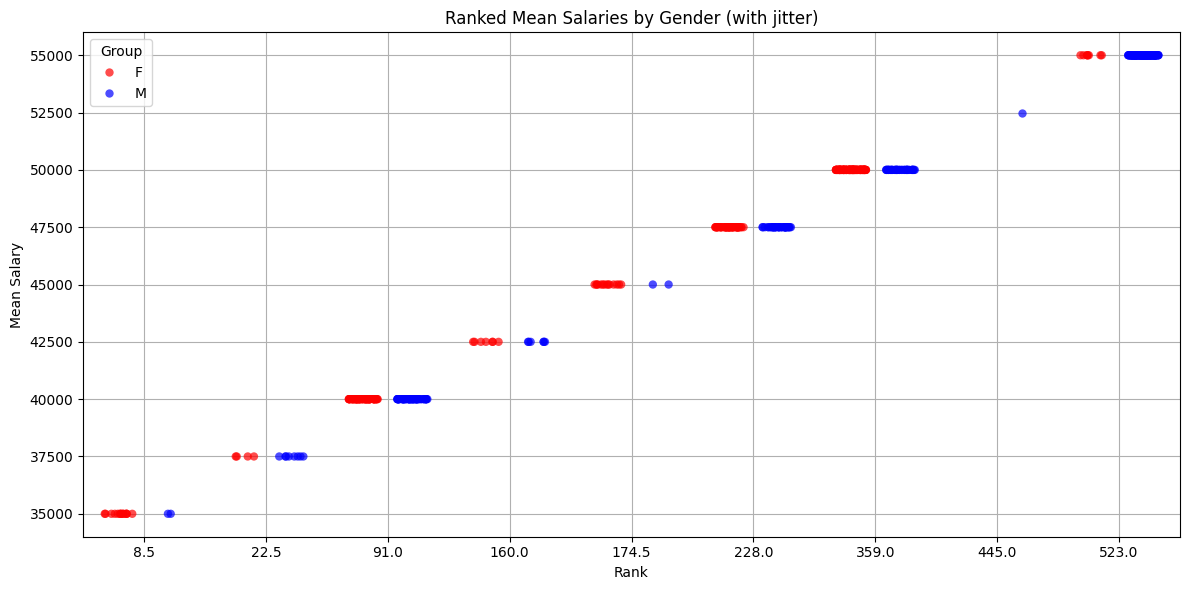

In [6]:
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=ranked_df,
    x='rank',
    y='value',
    hue='group',
    palette={'M': 'blue', 'F': 'red'},
    jitter=0.25,   # Spread dots horizontally
    dodge=True,    # Separate M and F a bit
    alpha=0.7,
    size=6
)

plt.title('Ranked Mean Salaries by Gender (with jitter)')
plt.xlabel('Rank')
plt.ylabel('Mean Salary')
plt.legend(title='Group')
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
# Extract values
x = df_m["middle_salary"].values
y = df_f["middle_salary"].values

n1 = len(x)
n2 = len(y)

# Combine and rank
all_values = np.concatenate([x, y])
ranks = rankdata(all_values)

# Group labels
groups = ['M'] * n1 + ['F'] * n2

# Build DataFrame of ranks and groups
df_ranks = pd.DataFrame({
    'Rank': ranks,
    'Group': groups
})

# Group by unique rank and count each gender
summary_table = df_ranks.groupby(['Rank', 'Group']).size().unstack(fill_value=0).reset_index()

# Optional: Rename for clarity
summary_table.columns.name = None
summary_table = summary_table.rename(columns={'M': '# Male', 'F': '# Female'})

print(summary_table)

# Compute rank sums
R1 = df_ranks.loc[df_ranks['Group'] == 'M', 'Rank'].sum()
R2 = df_ranks.loc[df_ranks['Group'] == 'F', 'Rank'].sum()

print(f"R1 (Male rank sum): {R1:.1f}")
print(f"R2 (Female rank sum): {R2:.1f}")


    Rank  # Female  # Male
0    8.5        14       2
1   22.5         4       8
2   91.0        67      58
3  160.0         7       6
4  174.5        14       2
5  228.0        54      37
6  359.0       132      39
7  445.0         0       1
8  523.0         8     147
R1 (Male rank sum): 106547.0
R2 (Female rank sum): 73753.0


In [8]:
# Assign ranks back to original groups
ranks_x = ranks[:n1]
ranks_y = ranks[n1:]

# Sum ranks
R1 = np.sum(ranks_x)
R2 = np.sum(ranks_y)

# Compute U values
U1 = n1 * n2 + n1 * (n1 + 1) / 2 - R1
U2 = n1 * n2 + n2 * (n2 + 1) / 2 - R2

U = min(U1, U2)

# Compute mean and std for normal approximation
mu_U = n1 * n2 / 2
sigma_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)

# Compute Z-score
Z = (U - mu_U) / sigma_U

# Compute p-value
p_value = 2 * stats.norm.sf(abs(Z))  # Two-tailed test

print(f"U = {U:.2f}")
print(f"Z = {Z:.2f}")
print(f"abs(Z) = {abs(Z):.2f}")
print(f"From table, p is approximately {p_value} (two-tailed)")

if p_value < 0.05:
    print("p<0.05 : Ignore the next steps. We are not interested in the power.")
else:
    count = 0
    for xi in x:
        for yj in y:
            if xi > yj:
                count += 1

    A = count / (n1 * n2)
    print(f"Count of pairs (X > Y): {count}")
    print(f"Estimated A = P(X > Y) = {A:.4f}")

    
    # A is given from the previous calculation
    delta = abs(A - 0.5)

    alpha = 0.05
    z_alpha = norm.ppf(1 - alpha/2)  # 1.96 for two-tailed 0.05

    n1 = len(x)
    n2 = len(y)
    n = min(n1, n2)  # assume balanced sample size for approximation

    z_beta = np.sqrt(12) * delta * np.sqrt(n) - z_alpha
    power = norm.cdf(z_beta)

    print(f"Estimated power of Mann-Whitney U test: {power}")


U = 28603.00
Z = -7.72
abs(Z) = 7.72
From table, p is approximately 1.134568739112067e-14 (two-tailed)
p<0.05 : Ignore the next steps. We are not interested in the power.
